In [1]:

import sys
import os

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from parse_data import load_waveforms_until_eof
import json
from scipy.stats import binned_statistic
import pandas as pd


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# # run 64 at 8.5 bar, 78 at 7.5 bar, 82 at 6.5 bar, 85 at 5.5 bar, 87 at 4.5 bar, 106 at 3.5 bar


run_type = "alpha"  # "alpha" or "cosmic"

# pressure = 8.5 # bar
# if run_type == "alpha":
#     base = f"/Users/roberto/cigar/xe/alpha/{str(pressure).replace('.', '')}_bar"
#     pressures_run = {8.5: 64, 7.5: 78, 6.5: 82, 5.5: 83, 4.5: 86, 3.5: 105, 2.5: 111, 1.5: 114}
# elif run_type == "cosmic":
#     pressures_run = {8.5: 42, 7.5: 39, 6.5: 26, 5.5: 21, 4.5: 16, 3.5: 106, 2.5: 113, 1.5: 116, 0: 55}
#     base = f"/Users/roberto/cigar/xe/{str(pressure).replace('.', '')}_bar"
board_version = 2
# run = pressures_run[pressure]

base        = '/home/marian/CIGAR_ANALYSIS/CIGAR/data'
run         = 'Run117'
# run         = 'Run22'
run_dir     = f"{base}/{run}"

wfs = []

times = []
samples_per_waveform = 1124
# samples_per_waveform = 752

for f in glob(f"{run_dir}/*.bin"):
    wf, ts = load_waveforms_until_eof(
        f, channels=10, samples_per_waveform=samples_per_waveform, event_header_bytes=28
    )
    wfs.append(wf)
    times.extend(ts)
print(len(times))
run_duration = (np.array(times)).max() - (np.array(times)).min()
print(f"Run duration: {run_duration/1e9} s")

wfs_a = np.concatenate(wfs)
# wfs_a_35 = np.concatenate(wfs)

integrals = []
integrals_no_cosmic = []


if board_version == 1:
    not_amplified_offsets = [369, 410, 350, 408]
    # amplified_offsets = [600, 600, 600, 600]
    amplified_offsets = [550, 600, 550, 600]
    amplified_channels = [3, 5, 7, 9]
    not_amplified_channels = [2, 4, 6, 8]
    polarity = 1
    # integration_t0 = 220
    integration_t0 = 220
    # integration_t0 = 70
elif board_version == 2:
    not_amplified_channels = [3, 5, 7, 9]
    amplified_channels = [2, 4, 6, 8]
    # not_amplified_offsets = np.array([412.7, 353.7, 413.7, 373.3])
    not_amplified_offsets = np.array([414, 356, 375, 416])
    # amplified_offsets = [600,600,600,600]
    # amplified_offsets = [572.65, 589.88, 589.06, 549.06]
    amplified_offsets = [543, 550, 527, 556]
    polarity = -1
    integration_t0 = 70
    # integration_t0 = 0


if board_version == 2:
    # _=ax.hist(wfs_a[:, not_amplified_channels[0], :20].flatten(),bins=50,range=(410,430))
    # _=ax.hist(wfs_a[:, not_amplified_channels[1], :20].flatten(),bins=50,range=(340, 360))
    # _=ax.hist(wfs_a[:, not_amplified_channels[2], :20].flatten(),bins=50,range=(410,430))
    # _=ax.hist(wfs_a[:, not_amplified_channels[3], :20].flatten(),bins=50,range=(370, 390))
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[0], :120]),color='r')
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[1], :120]),color='r')
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[2], :120]),color='r')
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[3], :120]),color='r')
    medians = [np.median(wfs_a[:, not_amplified_channels[i], :120]) for i in range(4)]
    not_amplified_offsets = np.array(medians)

elif board_version == 1:

    # _=ax.hist(wfs_a[:, not_amplified_channels[0], :120].flatten(),bins=50,range=(-430,-300))
    # _=ax.hist(wfs_a[:, not_amplified_channels[1], :120].flatten(),bins=50,range=(-430,-300))
    # _=ax.hist(wfs_a[:, not_amplified_channels[2], :120].flatten(),bins=50,range=(-430,-300))
    # _=ax.hist(wfs_a[:, not_amplified_channels[3], :120].flatten(),bins=50,range=(-430,-300))
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[0], :120]),color='r')
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[1], :120]),color='r')
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[2], :120]),color='r')
    # ax.axvline(np.median(wfs_a[:, not_amplified_channels[3], :120]),color='r')
    medians = [np.median(wfs_a[:, not_amplified_channels[i], :120]) for i in range(4)]
    not_amplified_offsets = np.array(medians)

if run_type == "cosmic":
    integration_length = 200  # samples
else:
    integration_length = 1000  # samples
    integration_length = 1000
integration_window = slice(integration_t0, integration_t0 + integration_length)

time_ticks = np.linspace(0, 6.012, samples_per_waveform)

# mask = np.min(wfs_a, axis=(1, 2)) > -2000 # Peltier noise filter
# Peltier noise filter

mask = (
    (np.min(wfs_a[:, amplified_channels[0], :300] + amplified_offsets[0], axis=1) > -200)
    & (np.min(wfs_a[:, amplified_channels[1], :300] + amplified_offsets[1], axis=1) > -200)
    & (np.min(wfs_a[:, amplified_channels[2], :300] + amplified_offsets[2], axis=1) > -200)
    & (np.min(wfs_a[:, amplified_channels[3], :300] + amplified_offsets[3], axis=1) > -200)
)

wfs_filtered = wfs_a[mask]
fig, ax = plt.subplots(2, 1, sharex=True, constrained_layout=True)

# random event int
event_idx = np.random.randint(0, len(wfs_filtered))

for m, k in enumerate(not_amplified_channels):
    ax[0].plot(
        time_ticks,
        polarity * (wfs_filtered[event_idx][k] - not_amplified_offsets[m]),
        alpha=1,
    )

for i, j in enumerate(amplified_channels):
    ax[1].plot(
        time_ticks,
        wfs_filtered[event_idx][j] / 1e3 + amplified_offsets[i] / 1e3,
        alpha=1,
    )

ax[1].set_xlabel("Time [$\mathrm{\mu}$s]")
ax[1].set_ylabel("Voltage [V]")
ax[0].set_ylabel("Voltage [mV]")

ax[0].axvline(time_ticks[integration_window.start], color="k", ls="--", lw=1)
ax[0].axvline(time_ticks[integration_window.stop], color="k", ls="--", lw=1)

# fill between integration window
# ax[0].set_ylim(-50, 50)
ax[0].legend(title="No amplification")
ax[1].legend(title=r"$\times300$ amplification")
ax[0].fill_betweenx(
    ax[0].get_ylim(),
    time_ticks[integration_window.start],
    time_ticks[integration_window.stop],
    color="gray",
    alpha=0.3,
)
# fig.savefig(f"{base}/wfs_xe_{run}.pdf")

70500
Run duration: 4.294878449 s


: 

In [80]:

amplified_integral = []
not_amplified_integral = []
amplified_amplitude = []
not_amplified_amplitude = []

for i in range(4):
    amplified_integral.append(
        np.trapz(
            wfs_filtered[:, amplified_channels[i], integration_window]
            + amplified_offsets[i],
            axis=1,
        )
    )
    not_amplified_integral.append(
        np.trapz(
            polarity*(wfs_filtered[:, not_amplified_channels[i], integration_window]
            - not_amplified_offsets[i]),
            axis=1,
        )
    )

    amplified_amplitude.append(
        np.max(
            wfs_filtered[:, amplified_channels[i], integration_window]
            + amplified_offsets[i],
            axis=1,
        )
    )
    not_amplified_amplitude.append(
        np.max(
            polarity*(wfs_filtered[:, not_amplified_channels[i], integration_window]
            - not_amplified_offsets[i]),
            axis=1,
        )
    )

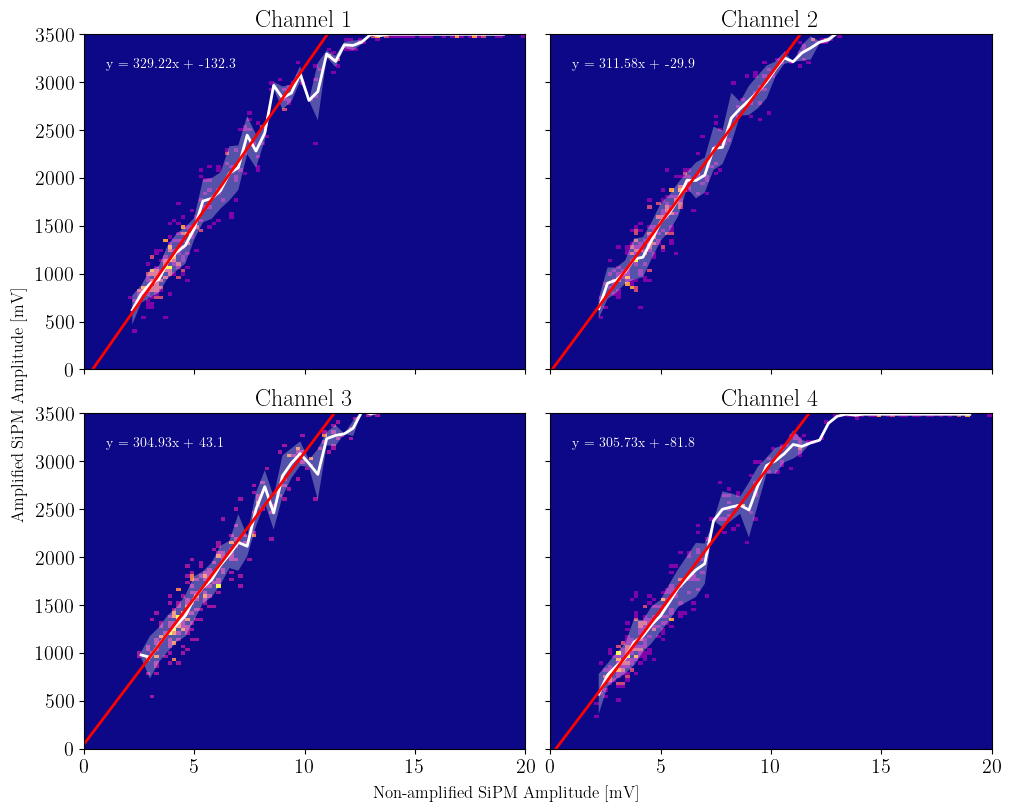

In [81]:

titles = [f"Channel {i+1}" for i in range(4)]

# --- Figure setup ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True, constrained_layout=True)
axs = axs.ravel()

# --- Common settings ---
bins = 50
xrange = (0, 20)
yrange = (0, 3500)
fit_range = (2.5, 10)

fee_coeffs_amplitude = {}

# --- Loop over channels ---
for i in range(4):
    ax = axs[i]
    x = not_amplified_amplitude[i]
    y = amplified_amplitude[i]

    # 2D histogram
    h, xedges, yedges, im = ax.hist2d(
        x, y, bins=100, range=[xrange, yrange], cmap='plasma'
    )

    # Mean profile
    mean, xedges, _ = binned_statistic(x, y, statistic='mean', bins=bins, range=xrange)
    std, _, _ = binned_statistic(x, y, statistic='std', bins=bins, range=xrange)
    xcenters = 0.5 * (xedges[1:] + xedges[:-1])

    # Overlay mean ± std
    ax.plot(xcenters, mean, color='white', lw=2, label='Mean profile')
    ax.fill_between(xcenters, mean-std, mean+std, color='white', alpha=0.3, lw=0)

    # Fit (linear in restricted range)
    mask = (xcenters > fit_range[0]) & (xcenters < fit_range[1]) & np.isfinite(mean)
    if np.count_nonzero(mask) > 2:
        coeffs = np.polyfit(xcenters[mask], mean[mask], deg=1)
        p = np.poly1d(coeffs)
        fee_coeffs_amplitude[i] = coeffs
        xfit = np.linspace(xrange[0], xrange[1], 400)
        yfit = p(xfit)
        ax.plot(xfit, yfit, 'r-', lw=2, label='Linear fit')
        ax.text(0.05, 0.9, f"y = {coeffs[0]:.2f}x + {coeffs[1]:.1f}", color='w', transform=ax.transAxes)

    # Labels and formatting
    ax.set_title(titles[i])
    ax.set_xlim(*xrange)
    ax.set_ylim(*yrange)

# --- Global labels ---
fig.supxlabel("Non-amplified SiPM Amplitude [mV]")
fig.supylabel("Amplified SiPM Amplitude [mV]")

out = {
    "run": int(run),
    "parameters": {
        "fee_coeffs": [
            ([float(fee_coeffs_amplitude[i][0]), float(fee_coeffs_amplitude[i][1])] if i in fee_coeffs_amplitude else None)
            for i in range(4)
        ],
    },
}

with open(f"{base}/fee_coeffs_amplitude_{run}.json", "w") as f:
    json.dump(out, f, indent=2)

Text(0.02, 0.5, 'Amplified SiPM integral [V$\\cdot$s]')

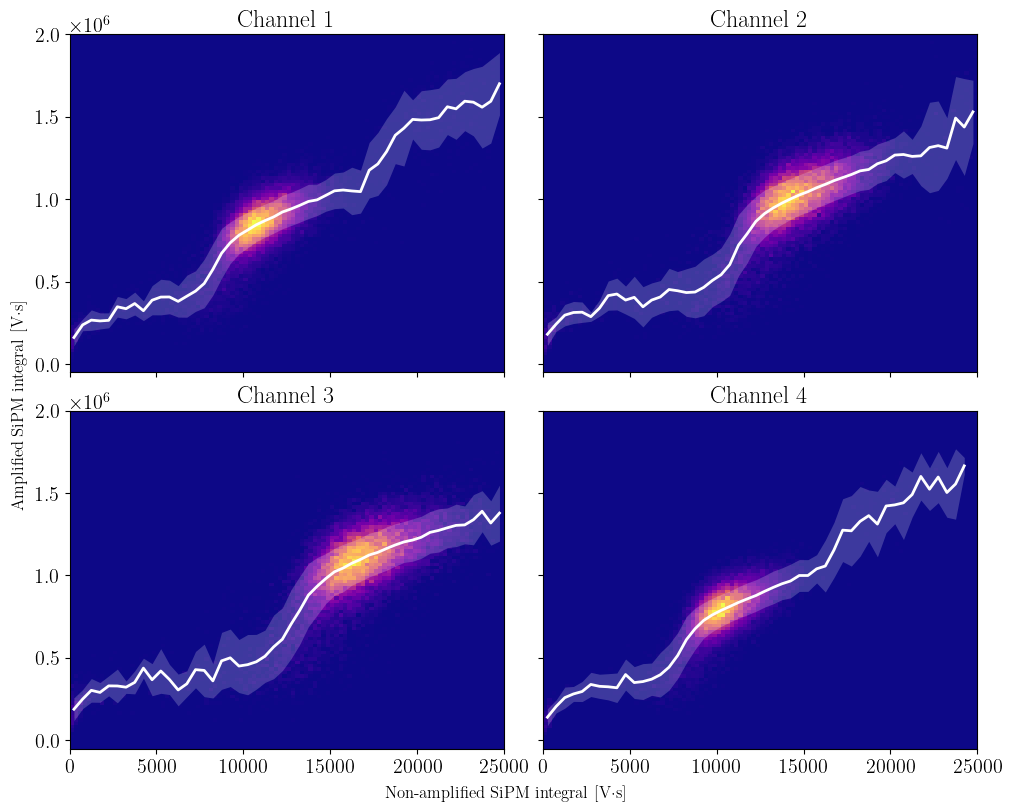

In [82]:

titles = [f"Channel {i+1}" for i in range(4)]

# --- Figure setup ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True, constrained_layout=True)
axs = axs.ravel()

# --- Common settings ---
bins = 50

if run_type == "alpha":
    xrange = (0, 2.5e4)
    yrange = (-5e4, 2e6)
    fit_range = (100,400)
elif run_type == "cosmic":
    xrange = (-500, 1e3)
    yrange = (-100000, 0.5e6)
    fit_range = (0,500)

fee_coeffs = {}

# --- Loop over channels ---
for i in range(4):
    ax = axs[i]
    x = not_amplified_integral[i]
    y = amplified_integral[i]

    # 2D histogram
    h, xedges, yedges, im = ax.hist2d(
        x, y, bins=100, range=[xrange, yrange], cmap='plasma'
    )

    # Mean profile
    mean, xedges, _ = binned_statistic(x, y, statistic='mean', bins=bins, range=xrange)
    std, _, _ = binned_statistic(x, y, statistic='std', bins=bins, range=xrange)
    xcenters = 0.5 * (xedges[1:] + xedges[:-1])

    # Overlay mean ± std
    ax.plot(xcenters, mean, color='white', lw=2, label='Mean profile')
    ax.fill_between(xcenters, mean-std, mean+std, color='white', alpha=0.2, lw=0)

    # Fit (linear in restricted range)
    mask = (xcenters > fit_range[0]) & (xcenters < fit_range[1]) & np.isfinite(mean)
    if np.count_nonzero(mask) > 2:
        coeffs = np.polyfit(xcenters[mask], mean[mask], deg=1)
        p = np.poly1d(coeffs)
        fee_coeffs[i] = coeffs
        xfit = np.linspace(xrange[0], xrange[1], 400)
        yfit = p(xfit)
        ax.plot(xfit, yfit, 'r-', lw=2, label='Linear fit')
        ax.text(0.05, 0.9, f"y = {coeffs[0]:.2f}x + {coeffs[1]:.1f}", color='w', transform=ax.transAxes)

    # Labels and formatting
    ax.set_title(titles[i])
    ax.set_xlim(*xrange)
    ax.set_ylim(*yrange)

# --- Global labels ---
fig.supxlabel(r"Non-amplified SiPM integral [V$\cdot$s]")
fig.supylabel(r"Amplified SiPM integral [V$\cdot$s]")

In [83]:
if run_type == "alpha":
    base_sipm_calib     = f"/Users/roberto/cigar/xe/alpha/{str(pressure).replace('.', '')}_bar"
elif run_type == "cosmic":
    if pressure == 3.5 or pressure == 2.5:
        base_sipm_calib     = "/Users/roberto/cigar/xe/alpha/25_bar/"
    elif pressure == 1.5:
        base_sipm_calib     = "/Users/roberto/cigar/xe/alpha/15_bar/"
    else:
        base_sipm_calib     = f"/Users/roberto/cigar/xe/{str(pressure).replace('.', '')}_bar"

base_ampli_calib    = f"/Users/roberto/cigar/xe/85_bar"

with open(f"{base_sipm_calib}/sipm_fit_params.json") as f:
    cfg = json.load(f)

gains = [ch["gain"] for ch in cfg["channels"]]
offsets = [ch["offset"] for ch in cfg["channels"]]

with open(f"{base_ampli_calib}/fee_coeffs_amplitude.json") as f:
    cfg_ampli = json.load(f)
    fee_coeffs_amplitude = {}
    for i, ch in enumerate(cfg_ampli["parameters"]['fee_coeffs']):
        fee_coeffs_amplitude[i] = ch

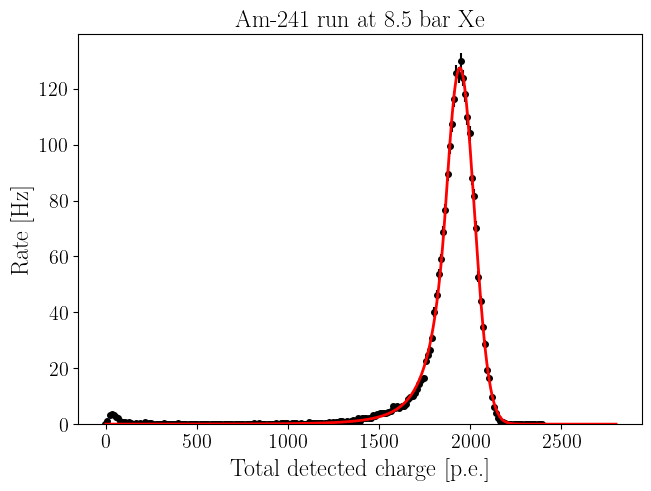

In [87]:
from scipy.stats import crystalball
def crystal_ball_pdf(x, A, beta, m, loc, scale):
    return A * crystalball.pdf(x, beta, m, loc=loc, scale=scale)

sum_amplified = sum((amplified_integral[i] - offsets[i]) / gains[i] for i in range(4))
event_type = "alpha"

if run_type == "cosmic":
    not_amplified_pe = [
        (np.poly1d(fee_coeffs[i])(not_amplified_integral[i]) - offsets[i])
        / gains[i]
        for i in range(4)
    ]
    sum_not_amplified = sum(
        not_amplified_pe
    )

not_amplified_pe_a = [
    (np.poly1d(fee_coeffs_amplitude[i])(not_amplified_integral[i]) - offsets[i])
    / gains[i]
    for i in range(4)
]


sum_not_amplified_a = sum(
    not_amplified_pe_a
)


fig, ax = plt.subplots(1, 1, constrained_layout=True)


if run_type == "alpha":
    x_range = (-10, 2400)
    n_bins = 200
    if event_type == "gamma":
        x_range = (-10, 200)
        n_bins = 50
else:
    x_range = (-10, 250)
    n_bins = 50

if run_type == "cosmic":
    n_cosmic, bins, patches = ax.hist(
        sum_not_amplified,
        bins=n_bins,
        range=x_range,
        histtype="step",
        color="k",
        lw=1.5,
        weights=np.ones_like(sum_not_amplified) / run_duration * 1e9,
    )
weights = np.ones_like(sum_not_amplified_a) / run_duration * 1e9

n,bins = np.histogram(
    sum_not_amplified_a+10,
    bins=n_bins,
    range=x_range,
    weights=weights,
)
hist_w2, _ = np.histogram(
    sum_not_amplified_a+10,
    bins=bins,
    weights=weights**2
)

errors = np.sqrt(hist_w2)
# n_err = np.sqrt(n * run_duration) / run_duration * 1e9
ax.errorbar(
    0.5 * (bins[1:] + bins[:-1]),
    n,
    yerr=errors,
    xerr=(bins[1]-bins[0])/2,
    fmt='o',
    color='k',
    markersize=4,
)


# ax.set_yscale("log")
ax.set_xlabel("Total detected charge [p.e.]")
ax.set_ylabel("Rate [Hz]")

if run_type == "alpha" and event_type=="gamma":
    def gauss(x, A, mu, sigma):
        return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    fit_range = (bin_centers > 0) & (bin_centers < 100)
    from scipy.optimize import curve_fit
    p0 = [1, 30, 10]
    # bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])
    popt, pcov = curve_fit(gauss, bin_centers[fit_range], n[fit_range], p0=p0)
    xfit = np.linspace(-10, x_range, 400)
    yfit = gauss(xfit, *popt)
    ax.plot(xfit, yfit, 'r', lw=2, label='Gaussian fit',zorder=np.inf)

if event_type == "alpha":
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    peak_mask = (bin_centers > 1000) & (bin_centers < 2700)
    # p0 = [max(n[peak_mask]), bin_centers[peak_mask][np.argmax(n[peak_mask])], 10]

    from scipy.optimize import curve_fit
    # popt, pcov = curve_fit(gauss, bin_centers[peak_mask], n[peak_mask], p0=p0)
    p0 = [3000, 1.15, 2.84, 1270, 50]
    # bounds = ([0, 0, 0, 1000, 10], [np.inf, np.inf, np.inf, 1500, 300])
    popt, pcov = curve_fit(crystal_ball_pdf, bin_centers[peak_mask], n[peak_mask], p0=p0)
    # popt[-1] *= 0.95
    # popt[0] *= 0.95
    xfit = np.linspace(0, 2800, 400)
    yfit = crystal_ball_pdf(xfit, *popt)
    ax.plot(xfit, yfit, 'r', lw=2, label='Crystal Ball fit',zorder=np.inf)

# # # ax.legend()
#     ax.text(popt[3]*0.4, 50, fr"\noindent $\mu$: {popt[3]:.1f} p.e.\\$\sigma$: {popt[4]:.1f} p.e.")

out = {
    "run": int(run),
    "run_duration_ns": int(run_duration),
    "sum_not_amplified": np.asarray(sum_not_amplified, dtype=float).tolist() if run_type == "cosmic" else np.asarray(sum_not_amplified_a, dtype=float).tolist(),
    # "fit_popt": np.asarray(popt, dtype=float).tolist(),
    # "fit_pcov": np.asarray(pcov, dtype=float).tolist(),
    "channels_not_amplified": np.asarray(not_amplified_pe, dtype=float).tolist() if run_type == "cosmic" else np.asarray(not_amplified_pe_a, dtype=float).tolist(),
    "parameters": {
        "gains": [float(g) for g in gains],
        "offsets": [float(o) for o in offsets],
        "fee_coeffs": [
            ([float(fee_coeffs[i][0]), float(fee_coeffs[i][1])] if i in fee_coeffs else None)
            for i in range(4)
        ],
    },
}
# ax.set_xlim(500, 2500)
ax.set_ylim(bottom=0)
# ax.set_yscale("log")
# ax.set_yscale("log")
ax.set_title(f"Am-241 run at {pressure} bar Xe")
# ax.set_xlim(0,100)
with open(f"{base}/sum_not_amplified_run{run}_60keV.json", "w") as f:
    json.dump(out, f, indent=2)
# ax.set_ylim(0,5)
# ax.axvline(30)

fig.savefig(f"{base}/sum_not_amplified_run{run}.pdf")